# Exploratory Data Analysis — Credit Risk

Dataset: Give Me Some Credit (Kaggle) — 150k samples

**Goal:** Understand the data before building any model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/cs-training.csv', index_col=0)
print(f'Shape: {df.shape}')
df.head()

Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 1. Target Distribution

How many clients defaulted vs did not?

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Default rate: 6.68%


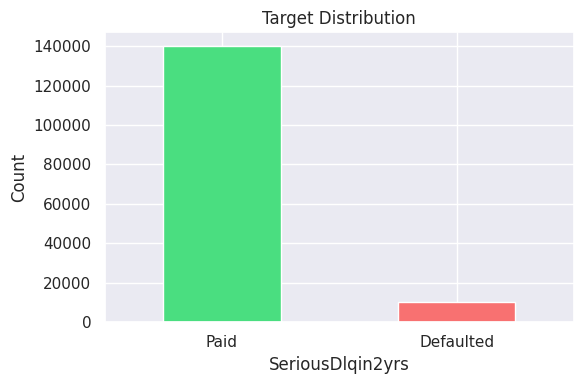

In [3]:
print(df['SeriousDlqin2yrs'].value_counts())
print(f'\nDefault rate: {df["SeriousDlqin2yrs"].mean():.2%}')

fig, ax = plt.subplots(figsize=(6, 4))
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar', ax=ax, color=['#4ade80', '#f87171'])
ax.set_xticklabels(['Paid', 'Defaulted'], rotation=0)
ax.set_title('Target Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 2. Missing Values

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
missing_df[missing_df['count'] > 0].sort_values('percent', ascending=False)

,count,percent
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


## 3. Basic Statistics

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


## 4. Outliers and Suspicious Values

Look for impossible or extreme values.

In [12]:
print('Age range:', df['age'].min(), '-', df['age'].max())
print('Clients with age < 18:', (df['age'] < 18).sum())
print('Clients with age > 100:', (df['age'] > 100).sum())
print()
print('MonthlyIncome = 0:', (df['MonthlyIncome'] == 0).sum())
print('MonthlyIncome is null:', df['MonthlyIncome'].isnull().sum())
print()
print('RevolvingUtilization > 1 (over limit):', (df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum())
print('RevolvingUtilization > 10:', (df['RevolvingUtilizationOfUnsecuredLines'] > 10).sum())

Age range: 0 - 109
Clients with age < 18: 1
Clients with age > 100: 13

MonthlyIncome = 0: 1634
MonthlyIncome is null: 29731

RevolvingUtilization > 1 (over limit): 3321
RevolvingUtilization > 10: 241


## 5. Feature Distributions

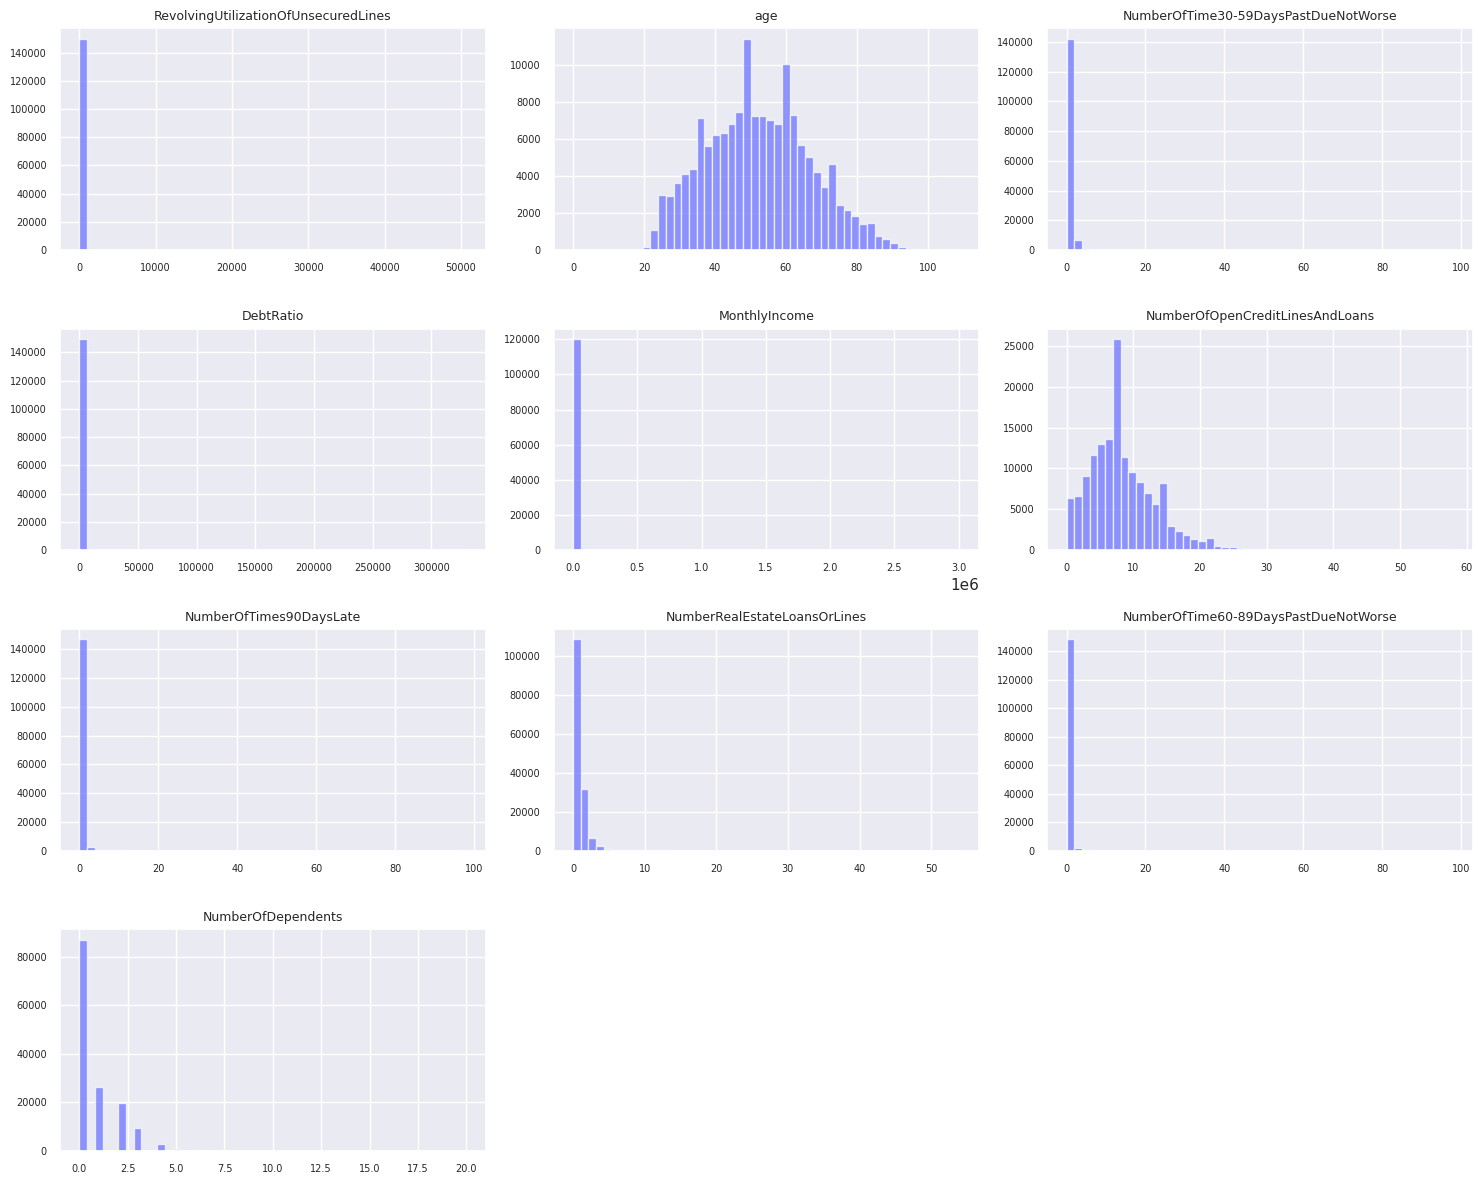

In [13]:
features = df.drop('SeriousDlqin2yrs', axis=1).columns

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    if i < len(axes):
        ax = axes[i]
        df[col].hist(bins=50, ax=ax, color='#646cff', alpha=0.7)
        ax.set_title(col, fontsize=9)
        ax.tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Correlation with Target

Which features are most correlated with default?

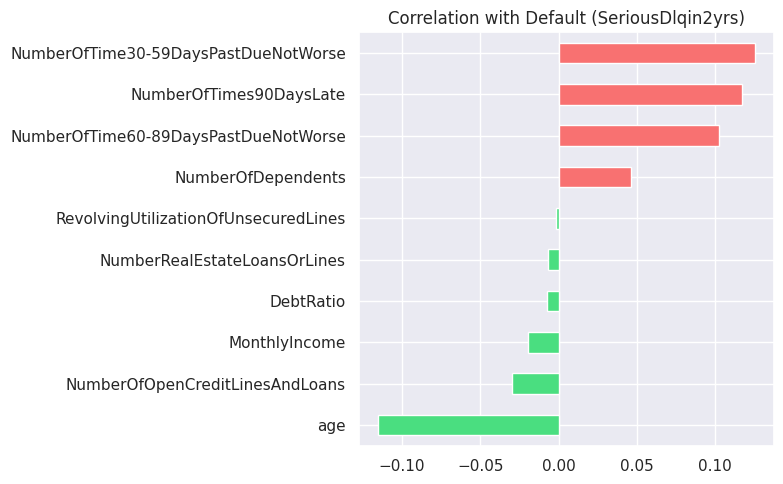

In [14]:
corr = df.corr()['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
corr.plot(kind='barh', ax=ax, color=['#f87171' if x > 0 else '#4ade80' for x in corr])
ax.set_title('Correlation with Default (SeriousDlqin2yrs)')
ax.axvline(x=0, color='white', linewidth=0.5)
plt.tight_layout()
plt.show()

## 7. Correlation Heatmap

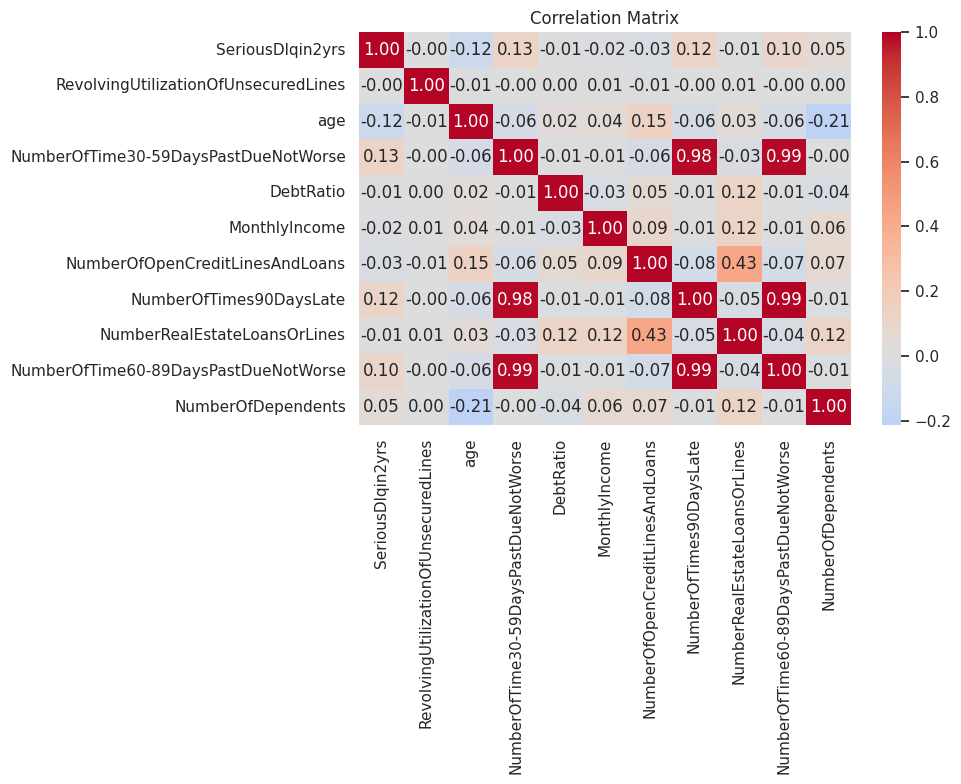

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 8. Default Rate by Feature Bins

How does default rate change across different ranges?

/tmp/ipykernel_1190767/3263982305.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default = df.groupby('age_group')['SeriousDlqin2yrs'].mean()


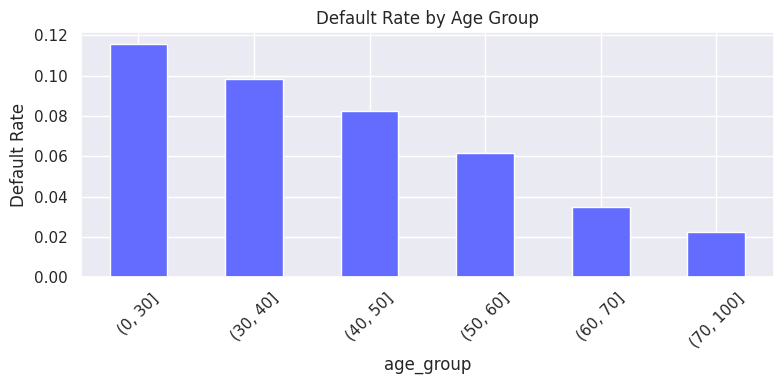

In [16]:
# Default rate by age group
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 70, 100])
age_default = df.groupby('age_group')['SeriousDlqin2yrs'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
age_default.plot(kind='bar', ax=ax, color='#646cff')
ax.set_title('Default Rate by Age Group')
ax.set_ylabel('Default Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

df.drop('age_group', axis=1, inplace=True)

In [19]:
# Default rate by number of late payments (90+ days)
late_default = df.groupby('NumberOfTimes90DaysLate')['SeriousDlqin2yrs'].mean().head(10)
late_default


NumberOfTimes90DaysLate
0    0.046265
1    0.336639
2    0.499035
3    0.577211
4    0.670103
5    0.633588
6    0.600000
7    0.815789
8    0.714286
9    0.736842
Name: SeriousDlqin2yrs, dtype: float64

## 9. Key Findings

1. **Target balance:** Heavily imbalanced — ~93% paid, ~7% defaulted. Will need balancing techniques (SMOTE, class weights) during model training.

2. **Missing values:** MonthlyIncome has ~20% missing (29,731 rows). NumberOfDependents has ~2.6% missing (3,924 rows). The fact that income is missing may itself be a predictive signal.

3. **Outliers:**
   - age: 1 client with age=0 (invalid), 13 clients with age > 100 (suspicious)
   - RevolvingUtilizationOfUnsecuredLines: 241 clients with values > 10 (likely data errors)
   - DebtRatio: extreme values up to 300,000 (needs capping)
   - MonthlyIncome: 1,634 clients with income=0 (unemployed or data error)

4. **Most predictive features:**
   - Late payment history (30-59, 60-89, 90+ days) — strongest positive correlation with default
   - Age — strongest negative correlation (younger clients default more)
   - Just 1 late payment of 90+ days increases default rate from 4% to 35%

5. **Feature engineering ideas:**
   - Combine the 3 late payment columns into a single `total_late_payments` feature (correlation between them is 0.98-0.99)
   - Cap RevolvingUtilization at 1.5 to remove extreme outliers
   - Create `income_missing` flag column before filling nulls
   - Fill MonthlyIncome nulls with median, NumberOfDependents with median
   - Remove or cap age < 18 and age > 100